# **Ievads attēlu apstrādē**

## **Praktiskais darbs Nr. 6**

---

**Students:** Edgars Polis

**Studenta apliecības Nr.:** 241RDB296

**Saite uz programmēšanas kodu:** https://github.com/Edgars-P/RTU_IAA_MD/blob/main/LD6/IAA_LD6.ipynb

---

**Attēla segmentēšana**


## **Programmas kods ar izvadi**


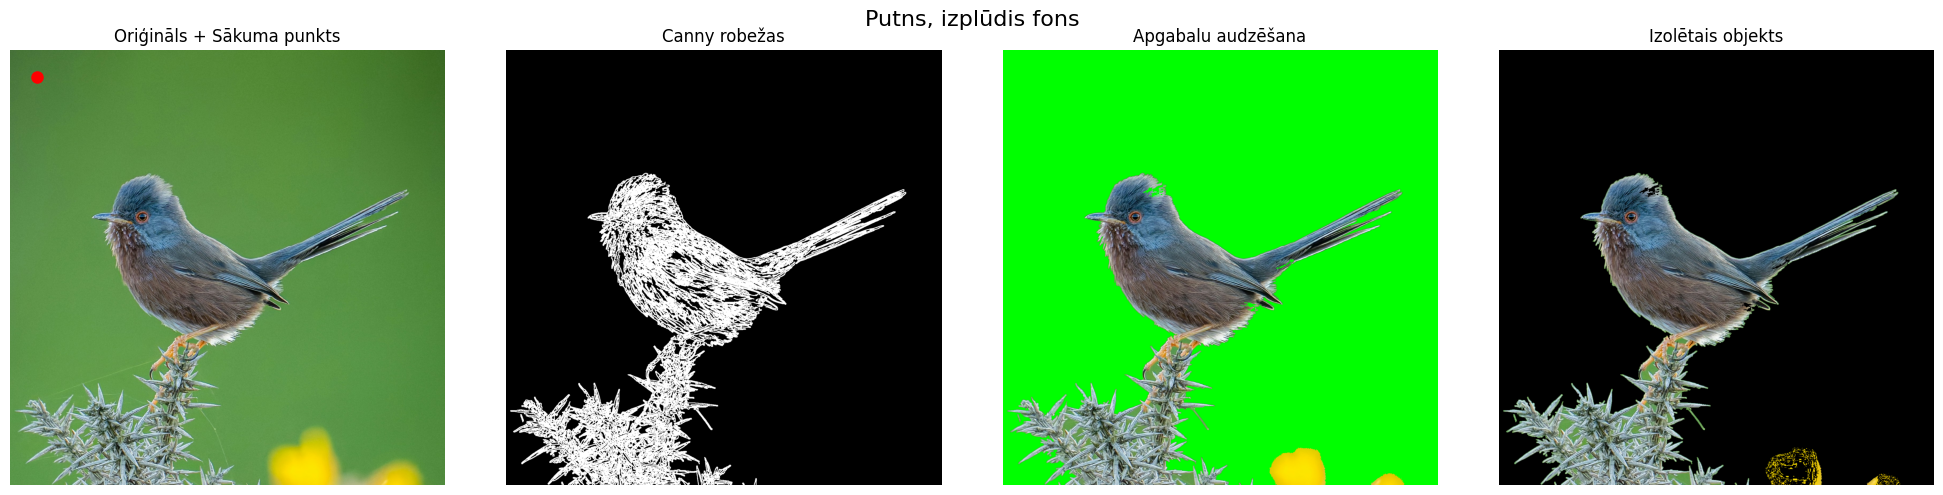

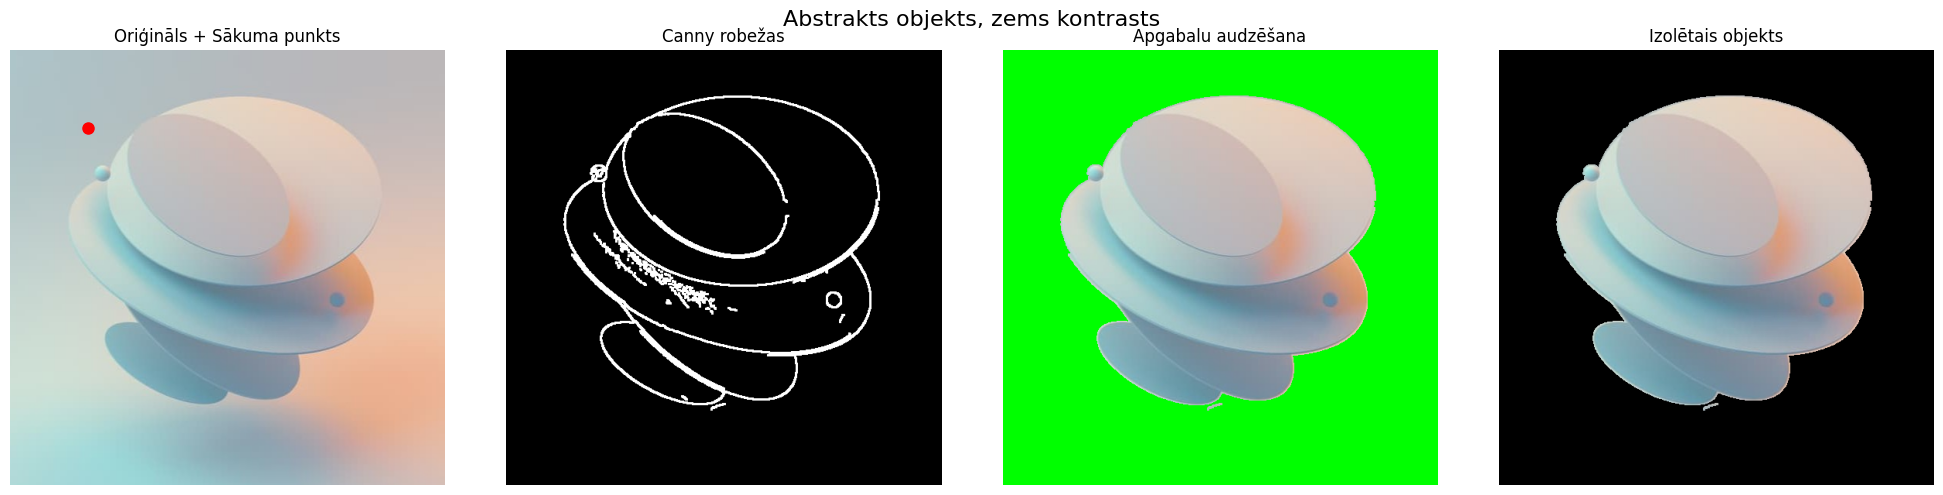

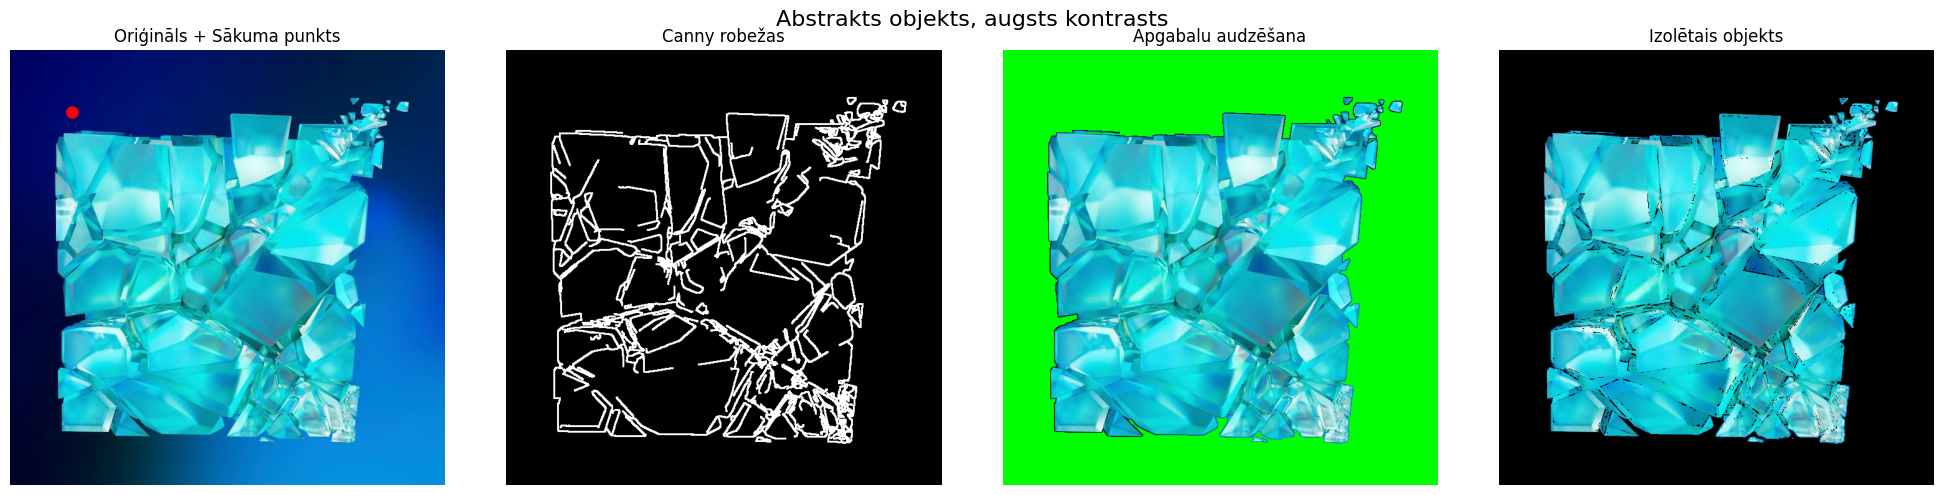

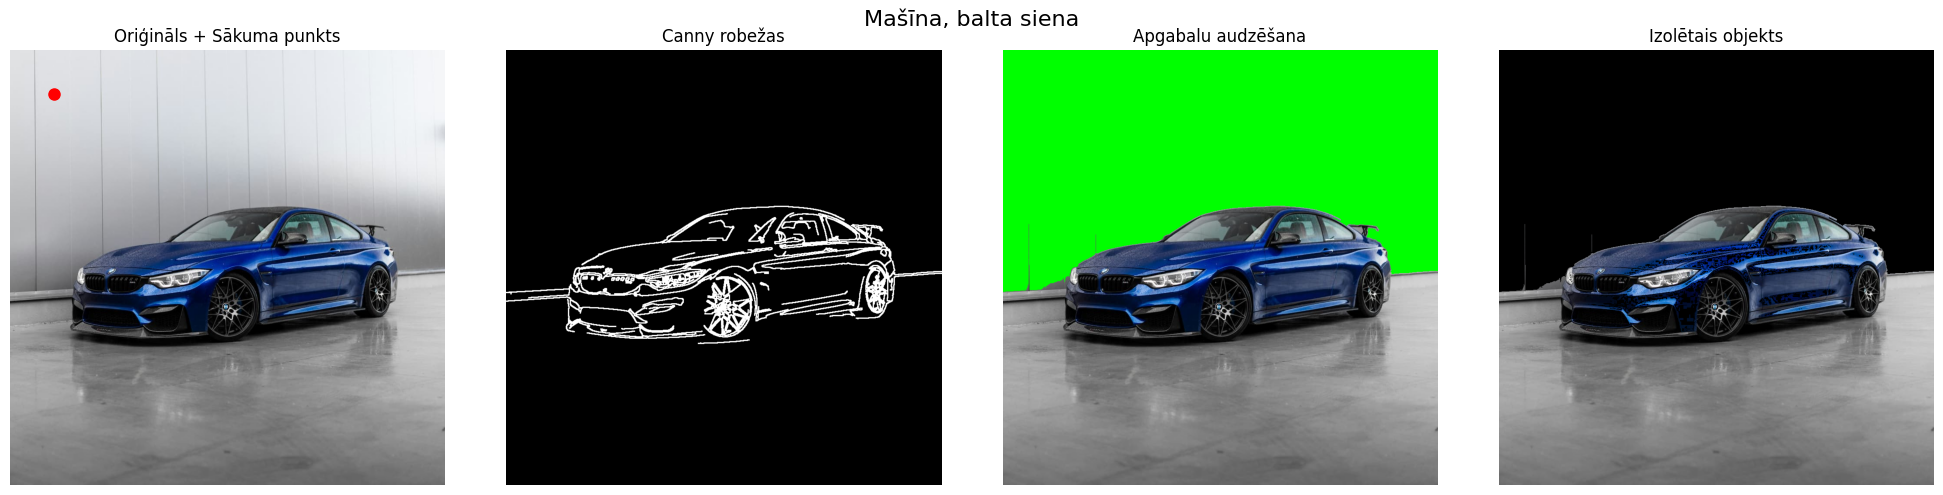

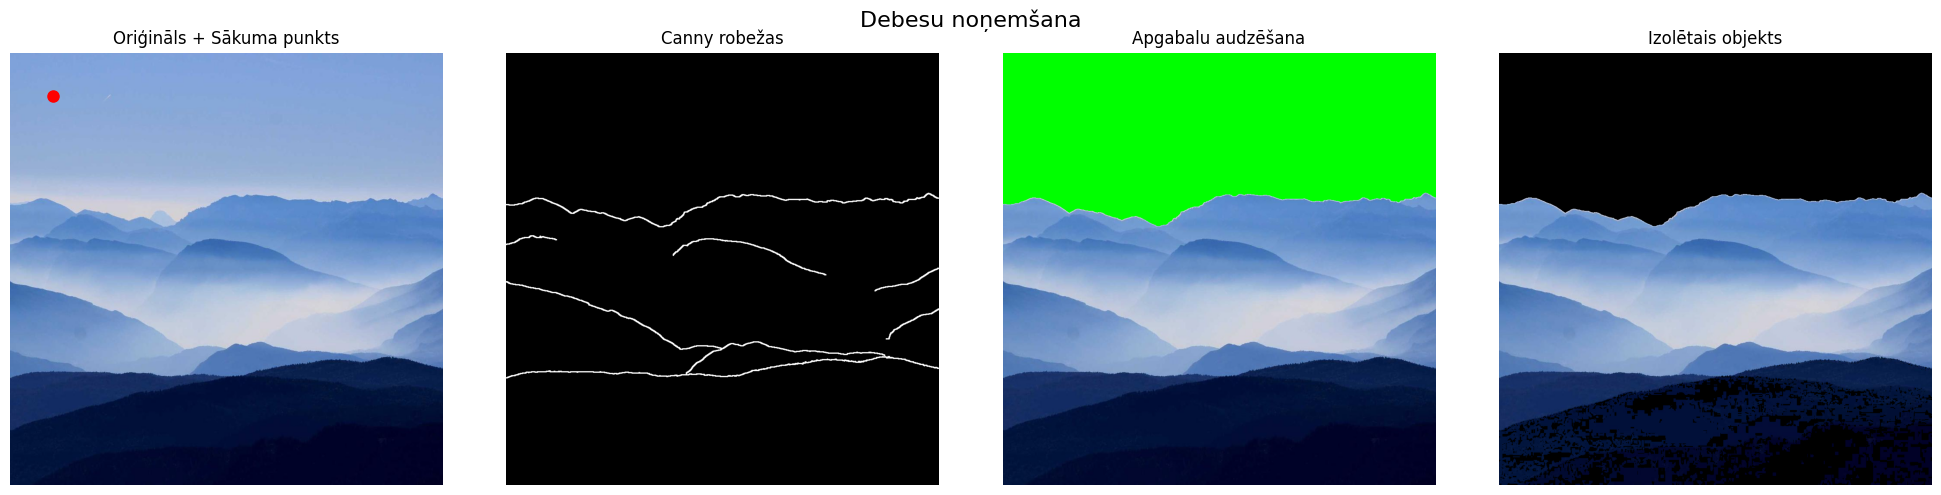

In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_display(image_path, title, seed_point, blur_ksize=5, canny_t1=50, canny_t2=150, tolerance=20):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Kļūda: Nevar ielādēt attēlu {image_path}")
        return
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    
    img_smoothed = cv2.GaussianBlur(img_rgb, (blur_ksize, blur_ksize), 0)
    
    img_gray = cv2.cvtColor(img_smoothed, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(img_gray, canny_t1, canny_t2)
    
    kernel = np.ones((3, 3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=1)
    
    mask = np.zeros((h + 2, w + 2), np.uint8)
    
    mask[1:h+1, 1:w+1] = edges_dilated
    
    img_filled = img_rgb.copy()
    fill_color = (0, 255, 0) 
    
    lo_diff = (tolerance, tolerance, tolerance)
    up_diff = (tolerance, tolerance, tolerance)
    
    cv2.floodFill(img_filled, mask, seed_point, fill_color, lo_diff, up_diff, cv2.FLOODFILL_FIXED_RANGE)
    
    segmented_mask = np.all(img_filled != fill_color, axis=-1)
    isolated_obj = np.zeros_like(img_rgb)
    isolated_obj[segmented_mask] = img_rgb[segmented_mask]
    
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    
    axs[0].imshow(img_rgb)
    axs[0].set_title("Oriģināls + Sākuma punkts")
    axs[0].plot(seed_point[0], seed_point[1], 'ro', markersize=8) 
    axs[0].axis("off")
    
    axs[1].imshow(edges_dilated, cmap='gray')
    axs[1].set_title("Canny robežas")
    axs[1].axis("off")
    
    axs[2].imshow(img_filled)
    axs[2].set_title("Apgabalu audzēšana")
    axs[2].axis("off")
    
    axs[3].imshow(isolated_obj)
    axs[3].set_title("Izolētais objekts")
    axs[3].axis("off")
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

process_and_display("./putns.jpg", "Putns, izplūdis fons", seed_point=(100, 100), tolerance=150, canny_t1=30, canny_t2=120)
process_and_display("./abstraksts.jpg", "Abstrakts objekts, zems kontrasts", seed_point=(100, 100), tolerance=150, canny_t1=8, canny_t2=20)
process_and_display("./lauskas.jpg", "Abstrakts objekts, augsts kontrasts", seed_point=(100, 100), tolerance=150, canny_t1=50, canny_t2=150)
process_and_display("./masina.jpg", "Mašīna, balta siena", canny_t1=70, canny_t2=200, seed_point=(100, 100), tolerance=120)
process_and_display("./kalni.jpg", "Debesu noņemšana", seed_point=(100, 100), tolerance=100)

Manis izvēlētā problēma ir attēlu segmentācija - kā attēlā atrast un izdalīt atšķirīgas daļas, pat ja tas nav perfekti skaidrs vai satur troksni. Šajā uzdevumā es izvēlējos apvienot Canny robežu detektoru ar apgabalu audzēšanas metodi.

Eksperimentu rezultātā secināju, ka šī metode salīdzinoši labi spēj noņemt fonu no attēliem ar vienmērīgu fonu. Praktiski tas varētu būt noderīgi kamerās ar ierobežotu apstrādes jaudu, lai panāktu vienkāršus efektus, piemēram, fona aizstāšanu vai izpludināšanu.

Algoritms sastāv no 3 galvenajiem soļiem:

- Attēla izpludināšana
  - Palīdz Canny algoritmam nākamajā solī ignorēt troksni un smalkas tekstūras.
- Canny robežu atrašana
  - Nosaka galvenās fiziskās kontūras attēlā.
- Apgabalu audzēšana
  - Izmanto Canny robežas kā stingras barjeras, neļaujot audzēšanas algoritmam tās šķērsot. Tas ļauj izmantot daudz lielāku tolerances parametru apgabalu audzēšanā, tādējādi sasniedzot un aizpildot daudz lielāku daļu no fona.

Kopumā esmu ļoti apmierināts ar šo risinājumu. Tas veiksmīgi apvieno apgabalu audzēšanas spēju aizpildīt lielus laukumus ar Canny algoritma stingrajām robežām.Parastā apgabalu audzēšanā pietiktu ar vienu "vāju" malas pikseli, lai fona segments ieplūstu objektā. Šādu noplūžu novēršana prasītu samazināt toleranci, kas savukārt riskētu neaizpildītu fona apgabalu. Canny algoritms šo problēmu atrisina – tam var iestatīt pietiekami zemu apakšējo slieksni, lai savienotu vājās vietas un izveidotu nepārtrauktu barjeru, pārāk neietekmējot pārējo attēlu un veiksmīgi novēršot noplūdes.
